## Q1

2991834.6734
final mean: 2991834.6733999965
5000 5000
-1540.625


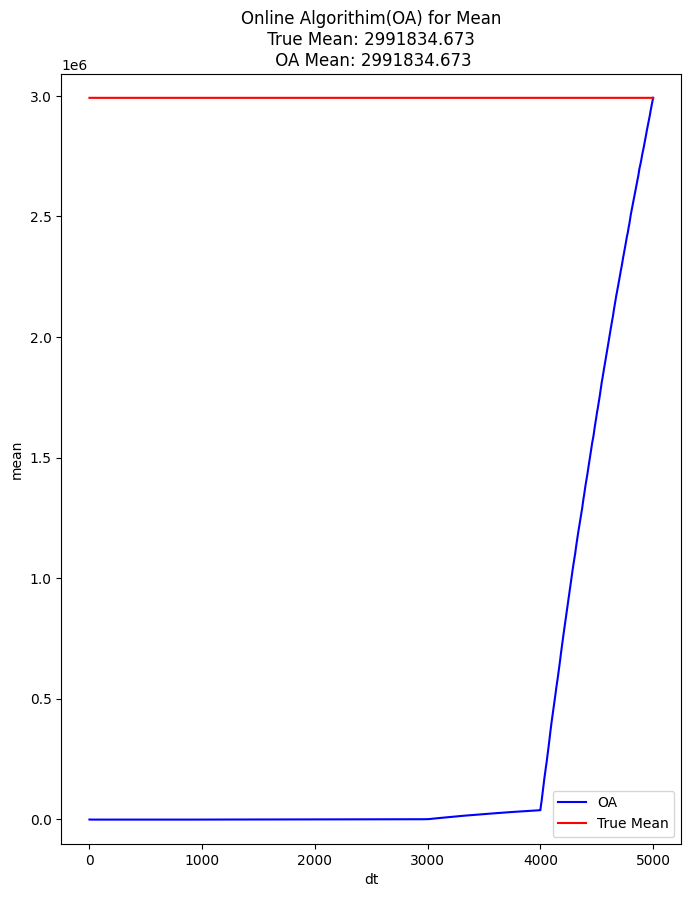

In [ ]:
# load libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# quick check data-1.txt has 5000 pts
# cat data-1.txt | wc -l -> 5000

# load data-1.txt
data = np.loadtxt('data-1.txt')

def online_algorithm_mean(data):
    mean_i = []
    dt = []
    current_mean = 0
    for t,x_t in enumerate(data):
        dt.append(t+1)
        current_mean = current_mean + ((x_t-current_mean)/(t+1))
        mean_i.append(current_mean)
    print(f"final mean: {mean_i[-1]}")
    return dt, mean_i

def plot_mean_dt(dt,mean_i,true_mean):
    fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(8,10))
    sns.lineplot(x=dt,y=mean_i,markers='o',ax=ax,color='blue',label='OA')
    sns.lineplot(x=dt,y=[true_mean for i in dt],markers='--',ax=ax,color='red',label='True Mean')
    ax.set_xlabel('dt')
    ax.set_ylabel('mean')
    ax.set_ylim(min(mean_i)-1e5,true_mean+1e5)
    print(min(mean_i))
    title = f"Online Algorithim(OA) for Mean\n True Mean: {true_mean:.3f} \n OA Mean: {mean_i[-1]:.3f}"
    ax.set_title(title)
    fig.savefig('hw3_q1.png')

# calc true mean and print it
true_mean = sum(data)/len(data)
print(true_mean)

dt, mean_i = online_algorithm_mean(data)
plot_mean_dt(dt,mean_i,true_mean)



## Q2

In [ ]:
# load libraries
import numpy as np

# load data-1.txt
data = np.loadtxt('data-1.txt')

def online_algorithm_variance(data):
    mean_x = 0.0
    mean_x_squared = 0.0
    variances = []

    for t,x_t in enumerate(data):
        # Update the mean of x
        mean_x = mean_x + ((x_t-mean_x)/(t+1))
        # Update the mean of x-squared
        mean_x_squared = mean_x_squared + ((x_t**2-mean_x_squared)/(t+1))
        
        variances.append(mean_x_squared - mean_x**2)

    print(f"final variance: {variances[-1]:.3f}")
    return variances

# calc true variance and print
true_variance = np.var(data)
print(f"true variance: {true_variance:.3f}")

# calc online_algorithm_variance
variances = online_algorithm_variance(data)

true variance: 36618966207041.938
final variance: 36618966207041.961


[np.float64(0.0),
 np.float64(3906.25),
 np.float64(2706.8888888885267),
 np.float64(38716.1875),
 np.float64(68106.24000000022),
 np.float64(79920.55555555597),
 np.float64(85206.24489795929),
 np.float64(76873.234375),
 np.float64(74886.88888888899),
 np.float64(68316.28999999957),
 np.float64(73783.47107437998),
 np.float64(70129.88888888853),
 np.float64(77181.32544378657),
 np.float64(75535.4540816322),
 np.float64(70504.55999999982),
 np.float64(66283.08984374977),
 np.float64(63668.463667819975),
 np.float64(67934.7283950618),
 np.float64(67024.99722991697),
 np.float64(69560.94749999978),
 np.float64(67401.55102040805),
 np.float64(68298.78719008225),
 np.float64(70671.5349716444),
 np.float64(68066.1388888883),
 np.float64(73480.71359999944),
 np.float64(72982.96597633092),
 np.float64(77639.80246913526),
 np.float64(75201.46301020356),
 np.float64(74385.44351961883),
 np.float64(72612.38222222123),
 np.float64(79301.28199791815),
 np.float64(76870.31249999953),
 np.float64(76

## Q3

In [ ]:
# load libraries
import numpy as np
import random

# load data-1.txt
data = np.loadtxt('data-1.txt')

def estimate_online_median(data, k, repetitions):

    print(f"--- Starting estimations for k={k} ---")
    for rep in range(repetitions):
        # initialize the sample array 's' with the first data point.
        # from s1=s2=...=sk=x1
        s = np.full(k, data[0])

        # get x_t from t=2,3,...,t
        for i in range(1, n):
            t = i + 1  
            x_t = data[i] 

            # for j=1,2,...,k then sj = xt with probability 1/t.
            for j in range(k):
                if random.random() < (1.0 / t):
                    s[j] = x_t
        
        # calculate the median of the final sample for each repetition
        estimated_median = np.median(s)
        print(f"repetition {rep + 1:2d}: estimated median = {estimated_median}")
    print("-" * (35 + len(str(k))))


# part (a): calc and print the true median
true_median = np.median(data)
print("--- true median calculation ---")
print(f"true median: {true_median}\n")

# part (b): simulation for k=100
estimate_online_median(data, k=100, repetitions=10)

# part (c): simulation for k=500
estimate_online_median(data, k=500, repetitions=10)


true median: 1526.000
--- True Median Calculation ---
The true median is: 1526.0

--- Starting estimations for k=100 ---
Repetition  1: Estimated Median = 1750.0
Repetition  2: Estimated Median = 1094.0
Repetition  3: Estimated Median = 1236.0
Repetition  4: Estimated Median = 1166.0
Repetition  5: Estimated Median = 1552.5
Repetition  6: Estimated Median = 1338.5
Repetition  7: Estimated Median = 1583.5
Repetition  8: Estimated Median = 1635.0
Repetition  9: Estimated Median = 1805.5
Repetition 10: Estimated Median = 1376.0
--------------------------------------
--- Starting estimations for k=500 ---
Repetition  1: Estimated Median = 1422.0
Repetition  2: Estimated Median = 1498.5
Repetition  3: Estimated Median = 1404.5
Repetition  4: Estimated Median = 1328.5
Repetition  5: Estimated Median = 1592.5
Repetition  6: Estimated Median = 1452.5
Repetition  7: Estimated Median = 1520.5
Repetition  8: Estimated Median = 1444.5
Repetition  9: Estimated Median = 1541.5
Repetition 10: Estimat

## Q6

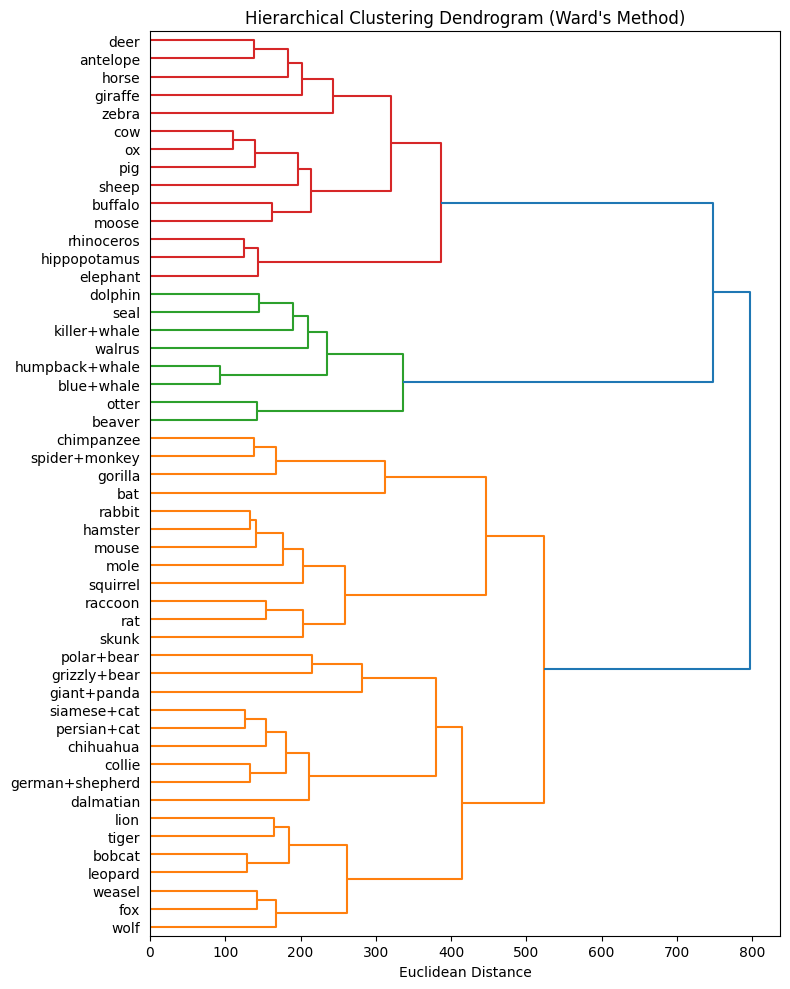

--- Ward's Method Clustering (k=10) ---
Cluster 1: tiger, leopard, fox, wolf, weasel, bobcat, lion
Cluster 2: dalmatian, persian+cat, german+shepherd, siamese+cat, chihuahua, collie
Cluster 3: grizzly+bear, giant+panda, polar+bear
Cluster 4: skunk, mole, hamster, squirrel, rabbit, rat, mouse, raccoon
Cluster 5: spider+monkey, gorilla, chimpanzee, bat
Cluster 6: beaver, otter
Cluster 7: killer+whale, blue+whale, humpback+whale, seal, walrus, dolphin
Cluster 8: hippopotamus, elephant, rhinoceros
Cluster 9: moose, ox, sheep, buffalo, pig, cow
Cluster 10: antelope, horse, giraffe, zebra, deer

K-means Cost for Ward's Clustering: 679136.2673

--- K-means Algorithm (10 runs) ---
Best K-means Cost found: 707405.1627


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
from sklearn.cluster import KMeans
from collections import defaultdict

# set plot figure size for better readability of the dendrogram
plt.rcParams['figure.figsize'] = (8, 10)

# read predicate-matrix-continuous.txt as numpy array
X = np.loadtxt('predicate-matrix-continuous.txt')

# read classes.txt to create animal name list
animal_names = []
with open('classes.txt', 'r') as f:
    for line in f:
        parts = line.strip().split()
        # The name is the second part, possibly with '+'
        animal_names.append(parts[1])

# perform hierarchical clustering using Ward's linkage method
Z = hierarchy.linkage(X, method='ward')

# plot the dendrogram
plt.figure()
hierarchy.dendrogram(
    Z,
    labels=animal_names,
    orientation='right',
    leaf_font_size=10
)
plt.title("Hierarchical Clustering Dendrogram (Ward's Method)")
plt.xlabel("Euclidean Distance")
plt.tight_layout()
plt.show()


# --- Part (b)(i): Get Ward's clusters and calculate its k-means cost ---

# get 10 clusters from the hierarchical model
ward_clusters = hierarchy.fcluster(Z, 10, criterion='maxclust')

# group animals by their assigned cluster
ward_cluster_dict = defaultdict(list)
for i, cluster_id in enumerate(ward_clusters):
    ward_cluster_dict[cluster_id].append(animal_names[i])

# calculate the k-means cost (sum of squared distances) for this clustering
ward_cost = 0.0
centroids = {}
for i in range(1, 11):
    # get all data points for the current cluster
    cluster_points = X[ward_clusters == i]
    # calculate the centroid (mean) of the cluster
    centroid = np.mean(cluster_points, axis=0)
    centroids[i] = centroid
    # calculate sum of squared distances from points to the centroid
    ward_cost += np.sum((cluster_points - centroid)**2)

print("--- wards clustering (k=10) ---")
for cid, animals in sorted(ward_cluster_dict.items()):
    print(f"cluster {cid}: {', '.join(animals)}")
print(f"\nkmeans cost for wards clustering: {ward_cost:.4f}")


# --- Part (b)(ii): Run k-means and find the best cost ---

# run kmeans 10 times with different random initializations
kmeans = KMeans(n_clusters=10, n_init=10, random_state=42)
kmeans.fit(X)

# inertia_ attribute stores the ssd (kmeans cost) for the best of the 10 runs
kmeans_cost = kmeans.inertia_

print("\n--- kmeans algorithm (10 runs) ---")
print(f"best kmeans cost found: {kmeans_cost:.4f}")